# [2주차] [5. ML] 과제
- **과제 목적**: Titanic 데이터 하나로 처음부터 ML의 과정을 끝까지 직접 밟아봅니다. 라이브러리 함수를 호출하는 데서 끝내지 않고, 학습의 핵심(loss, gradient descent)과 평가의 핵심(confusion matrix와 4대 지표)을 **손으로 직접 계산**해 개념을 체화합니다. 이어서 두 모델을 동일 조건에서 비교하고 성능 차이의 원인을 모델 구조 관점에서 해석합니다. 마지막 심화에서는 수업에서 그림으로만 본 overfitting을 실험으로 직접 재현합니다.

> ⚠️ **주의**: LLM를 써도 좋지만, **판단·검증·해석은 반드시 직접** 수행하고 사용 내역을 `## 3`에 기록하세요.


## 0. 환경 설정

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 7  # TODO: 랜덤한 숫자
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → survivied
- 이 데이터에는 label이 있다. 따라서 학습 방식은 지도학습이다.
- target이 (연속형 / 범주형) 이므로, 이 문제는 (회귀 / 분류) 문제다. → 정답: 범주형, 분류문제
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: 학습에 사용하지 않은 데이터에서도 모델이 생존 여부를 잘 예측하는지 평가하기 위해 데이터를 나눈다.


### 1-2. 전처리와 데이터 분할

아래 TODO를 채우고, **각 주석의 빈칸에 '왜 이 단계가 필요한지'를 직접 적으세요.


In [20]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): 
# age에는 결측치가 있어 그대로 두면 모델 학습에 문제가 생긴다. 나이는 이상치의 영향을 받을 수 있기 때문에 평균보다 안정적인 중앙값으로 채운다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명):
# 모델은 male, female 같은 문자열을 직접 계산할 수 없으므로 숫자로 변환한다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: stratify=y를 사용해 train과 test의 생존자/ 사망자 비율을 비슷하게 유지한다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=MY_SEED,
    stratify=y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | (2,4,6) | -18.86667 | 1.8667 |
| 2 | 1.8667 | (0.1333, 0.2667, 0.4000) | -1.2444 | 1.9911 |
| 3 | 1.9911 | (0.0089, 0.0178, 0.0267) | -0.0830 | 1.9994 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → 반복될수록 $w$가 2에 가까워지면서 각 데이터의 오차와 gradient의 크기가 작아졌다. $w$의 이동량은 -$\eta$ x $gradient$ 이므로 gradient가 작아질수록 $w$의 이동량도 작아진다. gradient가 0에 가까워져 $w$가 거의 변하지 않고 loss도 더 이상 크게 감소하지 않을 때 학습을 멈출 수 있다.


In [21]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2 / len(gx) * np.sum(gx * (gy - w * gx))  # 힌트: -2/len(gx) * np.sum(...)

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: gradient는 loss가 증가하는 방향을 가리키므로, loss를 줄이기 위해 gradient의 반대 방향으로 이동한다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요: 일치

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


### 1-4. 두 모델 학습과 비교

수업에서 "모든 알고리즘은 (f의 형태 / loss / 찾는 방법)에 대한 서로 다른 답"이라고 했습니다. 형태가 전혀 다른 두 모델을 **같은 데이터, 같은 조건**에서 학습시켜 비교합니다.

- **모델 A**: Logistic Regression (선형 + sigmoid)
- **모델 B**: Decision Tree (재귀 분할)


In [22]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서): 
    # train과 test 정확도를 비교하면 모델이 학습 데이터에만 지나치게 맞춰진 과적합 상태인지, 새로운 데이터에도 일반화되는지 확인할 수 있다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.8062 | test acc: 0.7598
Decision Tree        | train acc: 0.9831 | test acc: 0.8045


### 1-5. 평가지표 직접 유도

수업에서 "Confusion Matrix 하나에서 4개 지표가 전부 유도된다"고 했습니다. **sklearn의 지표 함수를 쓰기 전에**, TP/TN/FP/FN으로부터 직접 계산해 봅니다. (모델 A 기준)


In [18]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP + TN) / (TP + TN + FP + FN)
my_precision = TP / (TP + FP)  # [빈칸] precision의 분모에 들어가는 것과 그 의미: 분모 TP+FP -> 모델이 생존이라고 예측한 전체 인원
my_recall    = TP / (TP + FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: 분모 TP+FN -> 실제로 생존한 전체 인원
my_f1        = 2 * my_precision * my_recall / (my_precision + my_recall)  # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

Confusion Matrix:
 [[94 16]
 [22 47]]
TP=47, TN=94, FP=16, FN=22
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → Logistic Regression의 test 정확도는 0.7877, Decision Tree의 test 정확도는 0.8101였다. 이번 학습에 사용한 pclass, sex, age, fare 중 성별과 객실 등급은 생존 여부와 비교적 강한 관계가 있어 두 모델 모두 어느 정도 생존 여부를 예측할 수 있었다. 다만 가족 관계, 탑승항구, 객실 정보 등 다른 피처를 사용하지 않았기 때문에 정확도를 높이는 데에는 한계가 있었을 수도 있다고 생각한다.
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → Logistic Regression의 train-test 정확도 차이는 0.0115였고, Decision Tree의 차이는 0.1702였다. Logistic Regression은 하나의 선형적인 결정 경계를 사용하므로 복잡도가 비교적 낮아 train과 test 성능 차이가 작다. 반면에 DT는 피처를 반복적으로 분할하면서 학습 데이터를 세밀하게 구분할 수 있다. 그렇기 때문에 train 정확도는 높지만 test 정확도는 상대적으로 낮아져서 과적합이 발생한다.
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → MY_SEED를 기존 42에서 7로 변경했을 때 LR의 test 정확도는 기존값 0.7877에서 0.7598로 0.0279만큼 변했고, DT는 기존 0.8101에서 0.8045로 0.0056만큼 변했다. 시드에 따라 train/test에 포함되는 승객이 달라지므로 평가 결과도 달라진다. 이러한 우연에 따른 흔들림을 줄이기 위해 데이터를 여러 방식으로 나누어서 반복평가하는 교차 검증을 사용할 수 있다.
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → 
    과제를 시작하기 전에는 Decision Tree가 복잡한 관계를 학습하므로 Logistic Regression보다 test 정확도도 높을 것이라고 예상했다. 그러나 실제로는 DT의 trsin 정확도만 매우 높고 test 정확도는 생각보다 낮았다. 깊이에 제한이 없는 트리가 학습 데이터의 작은 특징과 노이즈까지 세밀하게 학습하여 과적합이 발생했기 때문이라고 생각한다.

## 2. 심화 과제 (선택)

### 2-1. Overfitting 직접 재현하기

 overfitting/underfitting curve를 **본인 데이터로 직접 그립니다.** Decision Tree의 `max_depth`를 1부터 15까지 바꿔가며 train/test 정확도를 기록하세요.


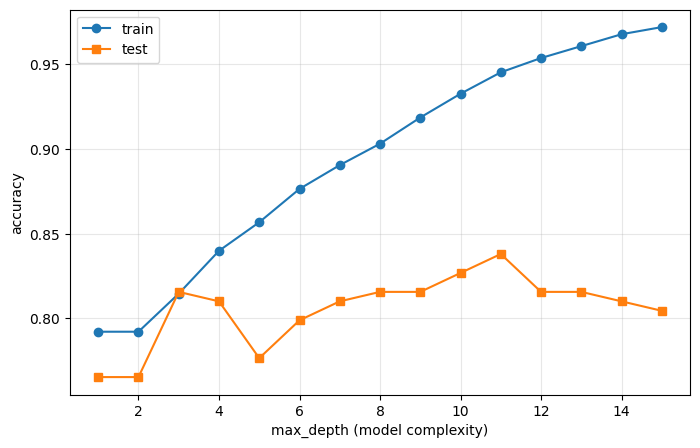

In [23]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고
    #       train/test 정확도를 각 리스트에 추가하세요
    model = DecisionTreeClassifier(max_depth=d, random_state=MY_SEED)
    model.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? 
# → max_depth가 1~2인 구간에서는 train 정확도와 test 정확도가 모두 낮은 약 0.79와 0.77에 머물러 있으므로 모델이 데이터의 패턴을 충분히 학습하지 못한 underfitting구간으로 볼 수 있다.
# → max_depth가 12~15인 구간에서는 train 정확도가 약 0.95 이상으로 계속 증가하지만 test 정확도는 약 0.82dptj 0.80까지 감소한다. 이 부분이 모델이 학습 데이터에 지나치게 맞춰지는 overfitting 구간으로 볼 수 있다.
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? → 최적의 max_depth는 11이다. 이때 test 정확도가 약 0.84로 가장 높았기 때문이다. 11보다 커지면 train 정확도는 상승하지만 test 정확도가 하락한다.
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → 트리 깊이가 증가할수록 모델이 학습 데이터를 더 세밀하게 분할하여
#   train 정확도는 약 0.18정도 증가했다. 하지만 test 정확도는 깊이가 11인 이후로 감소했다. 따라서 train loss를 낮추거나 train 정확도를 높이는 것은 쉽지만, 그것이 새로운 데이터에 대한 일반화 성능 향상을 보장하지는 않는다.

### 2-2. 비지도학습 미리보기 — label을 가리면 무엇이 보일까?

지금까지는 `survived`라는 label을 알고 학습했습니다(지도학습). 이번엔 **label을 일부러 가리고**, 데이터의 구조만으로 무엇이 보이는지 확인합니다.


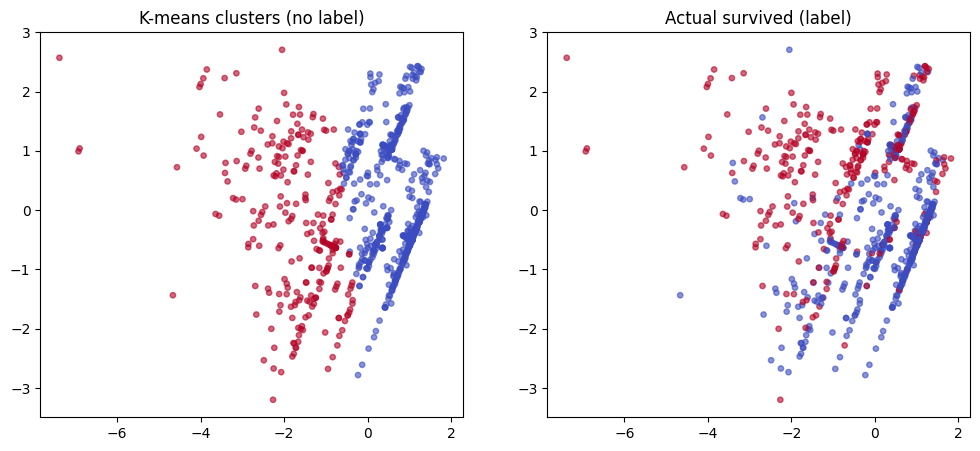

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유 (fare와 age의 단위를 생각해 보세요): 피처의 단위와 값의 범위가 다르기 때문에 특정 피처가 거리 계산을 지나치게 지배하지 않도록 스케일링한다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components=2).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_scaled)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
# ⚠️ c=y 로 넘기면 pandas Series를 단일 RGBA로 오해해 ValueError가 난다. 반드시 c=y.values
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

# 해석 (필수):
# - K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가? → 일부 겹치지만 완전히 일치하지는 않는다. 왼쪽 영역은 빨간색 군집과 실제 생존자가 상대적으로 많이 나타났고,
#   오른쪽 영역에는 파란색 군집과 실제 사망자가 많이 나타나는 경향을 보인다. 그러나 실제 생존 여부 그래프에서는 같은 영역 안에도 생존자와 사망자가 섞여있기에 두 군집을 생존/사망 집단으로 정확히 대응시키는건 무리다.
# - 겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가? 
#   (힌트: K-means는 무엇을 기준으로 데이터를 나누는가?) → K-means는 생존 여부 label을 사용하지 않고 pclass, sex, age, fare가 비슷한 승객끼리 유클리드 거리를 기준으로 군집화한다.
#   이러한 피처가 생존 여부와 어느 정도 관련되어 있어 두 결과가 부분적으로 비슷하게 나타났지만, K-means의 목적은 생존자를 구분하는 것이 아니라 피처가 가까운 데이터를 묶는 것이다. 또한 생존 여부는
#   현재 사용한 네가지 피처만으로는 완전히 결정할 수 없기 때문에 실제 라벨과 군집이 정확히 일치하지 않는다.

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → 사용하지 않음
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `______`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
(대화 내역)
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → 없음
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → train 정확도만으로 모델을 평가하면 과적합을 발견하기 어렵기 때문에, test 정확도와의 차이를 함께 확인해야 한다. 특히 복잡한 결정트리는 학습 데이터를 세밀하게 분할하여 train 성능은 높지만 새로운 데이터에 대한 성능은 낮아질 수 있다.
